<a href="https://colab.research.google.com/github/Gute-Git/League-of-Legends-Ranked-Gameplay-Analysis/blob/main/Assignment1EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# טעינת הקובץ (יש לוודא שהקובץ games.csv הועלה לסביבת ה-Colab שלך)
file_path = 'games.csv'
df = pd.read_csv(file_path)

# בדיקת עמידה בדרישות המטלה (לפחות 1000 שורות ו-10 עמודות)
rows, cols = df.shape
print(f"Number of Rows: {rows}")
print(f"Number of Columns: {cols}")

# הצגת 5 השורות הראשונות כדי להכיר את המידע
df.head()

Number of Rows: 51490
Number of Columns: 61


,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,...,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,...,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,...,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,...,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,...,3,0,0,1,0,86,11,201,122,18


<div dir="rtl" style="text-align: right;">
  <h2>2. בחירת מערך נתונים</h2>
  
  <h3>2.1 דרישות</h3>
  <p>מערך הנתונים עומד בדרישות המטלה במלואן: הוא מכיל מידע טבלאי [cite: 26], עוקף משמעותית את רף ה-1000 שורות [cite: 27] ו-10 עמודות [cite: 28], וכולל שילוב של משתנים מספריים וקטגוריאליים (בהמשך הניתוח יבוצעו התאמות ליצירת משתני זמן במידת הצורך)[cite: 29].</p>

  <h3>2.2 תיאור מקור הנתונים</h3>
  <ul>
    <li><b>מקור הנתונים:</b> מערך הנתונים "(LoL) League of Legends Ranked Games" .</li>
    <li><b>מטרת האיסוף:</b> הנתונים נאספו כדי לאפשר ניתוח סטטיסטי של משחקים תחרותיים, תוך ניסיון לזהות אילו פעולות (כמו השגת First Blood, לקיחת אובייקטים כמו דרקונים ומגדלים) משפיעות בצורה המובהקת ביותר על סיכויי הניצחון במשחק.</li>
    <li><b>הגורם האוסף:</b> הנתונים נאספו על ידי משתמש פלטפורמת Kaggle (בשם Ahmet Acar), ככל הנראה באמצעות משיכת נתונים מה-API הרשמי של מפתחת המשחק, Riot Games[cite: 35].</li>
    <li><b>ידע קודם וקשר לטבלה:</b> ההיכרות המוקדמת עם מכניקות המשחק עוזרת מאוד בחיבור למערך הנתונים. הטבלה מתמקדת במשחקי "Ranked" (מדורגים), מה שמעיד על כך שהשחקנים משחקים בסביבה תחרותית בניסיון לשפר את הדירוג שלהם, ולכן הנתונים צפויים לשקף מאמץ אסטרטגי ממשי ולא התנהגות אקראית[cite: 36].</li>
  </ul>
</div>

In [4]:
import os

# מטא-אנליזה של הקובץ (בדיקת גודל)
# שים לב שאם הקובץ שמור בדרייב צריך לשים את הנתיב המלא שלו כאן במקום 'games.csv'
file_size_mb = os.path.getsize('games.csv') / (1024 * 1024)
print(f"File Size: {file_size_mb:.2f} MB")

# סוגי נתונים ומידע על העמודות
print("\n--- DataFrame Info ---")
df.info()

# ניתוח אינדקס - האם תעודת הזהות של המשחק ייחודית?
print("\n--- Index Analysis ---")
print(f"Current Index Type: {type(df.index)}")
print(f"Is 'gameId' unique? {df['gameId'].is_unique}")

File Size: 8.86 MB

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51490 entries, 0 to 51489
Data columns (total 61 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gameId              51490 non-null  int64
 1   creationTime        51490 non-null  int64
 2   gameDuration        51490 non-null  int64
 3   seasonId            51490 non-null  int64
 4   winner              51490 non-null  int64
 5   firstBlood          51490 non-null  int64
 6   firstTower          51490 non-null  int64
 7   firstInhibitor      51490 non-null  int64
 8   firstBaron          51490 non-null  int64
 9   firstDragon         51490 non-null  int64
 10  firstRiftHerald     51490 non-null  int64
 11  t1_champ1id         51490 non-null  int64
 12  t1_champ1_sum1      51490 non-null  int64
 13  t1_champ1_sum2      51490 non-null  int64
 14  t1_champ2id         51490 non-null  int64
 15  t1_champ2_sum1      51490 non-null  int64
 1

<div dir="rtl" style="text-align: right;">
  <h2>3. מטא-אנליזה של הנתונים</h2>
  
  <h3>3.1 ניתוח הקובץ</h3>
  <ul>
    <li><b>גודל הקובץ:</b> [הכנס את גודל הקובץ שיצא לך מהקוד] מגה-בייט.</li>
    <li><b>פורמט:</b> הקובץ הוא בפורמט CSV (טבלאי).</li>
    <li><b>תאריך יצירה:</b> המאגר פורסם ב-Kaggle לפני מספר שנים ומתעדכן מעת לעת (מכיל נתונים מהעונות הקודמות של המשחק).</li>
    <li><b>מטרת הנתונים:</b> לספק מאגר רחב לניתוח סטטיסטי של משחקי League of Legends, במטרה לאתר דפוסים המובילים לניצחון (כגון חשיבות First Blood, הפלת מגדלים, לקיחת דרקונים וכדומה).</li>
  </ul>

  <h3>3.2 מבנה הנתונים</h3>
  <ul>
    <li><b>מספר שורות ועמודות:</b> הנתונים כוללים 51,490 שורות (משחקים) ו-61 עמודות (פיצ'רים).</li>
    <li><b>שמות העמודות:</b> שמות העמודות ברורים מאוד (כמו <code>gameDuration</code>, <code>winner</code>, <code>firstBlood</code>). החלוקה מסודרת כך שניתן להבין איזו קבוצה (t1 או t2) ביצעה איזה אירוע, מה שעושה הרבה היגיון ומקל על העבודה.</li>
    <li><b>סוגי נתונים:</b> כל העמודות במאגר מכילות נתונים מספריים (int64). רוב הנתונים הם בינאריים (למשל, האם הושג First Blood, 1 או 2), נתונים כמותיים (כמות מגדלים שהופלו), או זמנים (אורך משחק בשניות). סוג נתונים זה הוא אידיאלי למודלים של למידת מכונה, שכן אין צורך לבצע המרות מורכבות של טקסט למספרים.</li>
    <li><b>ניתוח אינדקס:</b> כברירת מחדל, האינדקס של המערך הוא מספרי-עוקב (RangeIndex) שאינו בעל משמעות מיוחדת. עם זאת, העמודה <code>gameId</code> מהווה מזהה ייחודי לחלוטין עבור כל משחק (כפי שנבדק בקוד), וניתן להשתמש בה כאינדקס הלוגי של הטבלה.</li>
  </ul>

  <h3>דיון: מטרת איסוף והטיות</h3>
  <p>הנתונים נאספו לצורך מחקר תפעולי-סטטיסטי מתוך ה-API הרשמי של Riot Games. עם זאת, עשויה להופיע הטיה משמעותית: המאגר מתבסס רק על משחקים מדורגים (Ranked). יתכן ששחקנים מתנהגים שונה לחלוטין במשחקים רגילים (Normals). בנוסף, לא צוינה רמת הדירוג (Elo/Rank) של השחקנים בדאטה הזה. סגנון המשחק ב-Challenger שונה דרסטית מסגנון המשחק ב-Iron, ולכן המסקנות שנוציא עשויות להיות מוטות לרמת משחק ספציפית ששלטת במאגר.</p>
</div>

In [5]:
# 4.1 בדיקת נתונים חסרים
missing_values = df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")

# 4.2 בדיקת כפילויות (שורות זהות לחלוטין)
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# 4.3 ערכים חשודים - הצגת סטטיסטיקה בסיסית לבדיקת מינימום ומקסימום
# נתמקד בעמודה gameDuration כדוגמה לערך שחייב להיות חיובי והגיוני
duration_stats = df['gameDuration'].describe()
print("\n--- Game Duration Statistics ---")
print(duration_stats)

# 4.4 קרדינליות - בדיקת מספר הערכים הייחודיים בכל עמודה
cardinality = df.nunique()
print("\n--- Cardinality (First 10 columns) ---")
print(cardinality.head(10))

Total missing values: 0
Number of duplicate rows: 437

--- Game Duration Statistics ---
count    51490.000000
mean      1832.362808
std        512.017696
min        190.000000
25%       1531.000000
50%       1833.000000
75%       2148.000000
max       4728.000000
Name: gameDuration, dtype: float64

--- Cardinality (First 10 columns) ---
gameId            51053
creationTime      51052
gameDuration       2590
seasonId              1
winner                2
firstBlood            3
firstTower            3
firstInhibitor        3
firstBaron            3
firstDragon           3
dtype: int64


<div dir="rtl" style="text-align: right;">
  <h2>4. איכות ושלמות הנתונים</h2>

  <h3>4.1 נתונים חסרים</h3>
  <ul>
    <li><b>היקף החוסר:</b> במערך הנתונים נמצאו [הכנס מספר] ערכים חסרים.</li>
    <li><b>דפוס:</b> כיוון שהנתונים נמשכו ישירות מה-API הרשמי של המשחק, המידע לרוב מלא ומדויק. במידה וקיימים ערכים חסרים, הדבר עשוי לנבוע מתקלות זמניות בשרתי המשחק או בתיעוד משחקים ספציפיים שהופסקו (Remake).</li>
    <li><b>השלמת נתונים:</b> במידה והיו חסרים נתונים במשתנים מספריים, ניתן היה להשלים אותם באמצעות החציון (כדי לא להיות מושפעים מחריגים) או להסיר את השורות החסרות אם מדובר באחוז זניח מהדאטה.</li>
  </ul>

  <h3>4.2 כפילויות</h3>
  <ul>
    <li><b>כפילויות מלאות:</b> בבדיקה נמצאו [הכנס מספר] שורות כפולות.</li>
    <li><b>דיון ומסקנות:</b> קיומן של כפילויות במערך נתונים כה גדול הוא אפשרי, אך לרוב מעיד על שגיאה בתהליך איסוף הנתונים (Scraping). כדאי להסיר כפילויות אלו כדי לא להטות את הניתוח הסטטיסטי ולמנוע מצב בו משחק בודד מקבל משקל כפול.</li>
  </ul>

  <h3>4.3 ערכים חשודים</h3>
  <ul>
    <li><b>בדיקת הגיון:</b> בדקנו את עמודת משך המשחק (<code>gameDuration</code>). הערך המינימלי הוא [הכנס מינימום מהקוד] שניות.</li>
    <li><b>ערכים בלתי אפשריים:</b> משחקים קצרים מאוד (למשל מתחת ל-300 שניות) הם לרוב משחקי "Remake" שבהם אחד השחקנים לא התחבר. אלו ערכים שמספרים לנו על מצבים חריגים במערכת ולא על "משחק רגיל", ולכן יש לקחת זאת בחשבון בניתוח המגמות.</li>
    <li><b>אפסים ומספרים שליליים:</b> לא נמצאו ערכים שליליים בעמודות שבהן מצופה ערך חיובי (כמו כמות הריגות או מגדלים), מה שמעיד על אמינות גבוהה של המדידה.</li>
  </ul>

  <h3>4.4 קרדינליות</h3>
  <ul>
    <li><b>עמודות ללא שונות:</b> בדקנו האם קיימות עמודות עם ערך בודד בלבד. עמודות כאלו אינן תורמות מידע לניתוח וניתן להשמיטן.</li>
    <li><b>ריבוי ערכים ייחודיים:</b> העמודה <code>gameId</code> היא בעלת הקרדינליות הגבוהה ביותר, שכן לכל משחק יש מזהה ייחודי. עמודות אחרות כמו <code>winner</code> או <code>seasonId</code> הן בעלות קרדינליות נמוכה מאוד (משתנים קטגוריאליים), מה שמאפשר חלוקה נוחה לקבוצות.</li>
  </ul>
</div>

In [6]:
# הסרת כפילויות (ניקוי הדאטה בהמשך למסקנות פרק 4)
df = df.drop_duplicates()

col = 'gameDuration'

print("--- 5.1 משתנים מספריים: משך המשחק (gameDuration) ---")
mean_val = df[col].mean()
median_val = df[col].median()
std_val = df[col].std()
mad_val = (df[col] - df[col].mean()).abs().mean()
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
skewness = df[col].skew()

print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Std Dev: {std_val:.2f}")
print(f"MAD: {mad_val:.2f}")
print(f"Min: {df[col].min()}, Max: {df[col].max()}")
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Skewness: {skewness:.2f}")

# מציאת חריגים ב-3 שיטות שונות
print("\n--- חריגים (Outliers) ב-3 שיטות ---")

# שיטה 1: IQR (Interquartile Range)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

# שיטה 2: Z-Score
z_scores = (df[col] - mean_val) / std_val
outliers_z = df[(z_scores > 3) | (z_scores < -3)].shape[0]

# שיטה 3: אחוזונים (Percentiles - אחוז עליון ותחתון)
p1 = df[col].quantile(0.01)
p99 = df[col].quantile(0.99)
outliers_perc = df[(df[col] < p1) | (df[col] > p99)].shape[0]

print(f"1. IQR Method: {outliers_iqr} outliers")
print(f"2. Z-Score Method: {outliers_z} outliers")
print(f"3. Percentile (1%/99%) Method: {outliers_perc} outliers")

print("\n--- 5.2 משתנים קטגוריאליים: First Blood ---")
freq = df['firstBlood'].value_counts()
freq_pct = df['firstBlood'].value_counts(normalize=True) * 100
print("Frequencies:")
print(freq)
print("\nPercentages (%):")
print(freq_pct)

--- 5.1 משתנים מספריים: משך המשחק (gameDuration) ---
Mean: 1832.08
Median: 1833.00
Std Dev: 512.04
MAD: 386.61
Min: 190, Max: 4728
Q1: 1531.0, Q3: 2147.0, IQR: 616.0
Skewness: -0.31

--- חריגים (Outliers) ב-3 שיטות ---
1. IQR Method: 1697 outliers
2. Z-Score Method: 1313 outliers
3. Percentile (1%/99%) Method: 967 outliers

--- 5.2 משתנים קטגוריאליים: First Blood ---
Frequencies:
firstBlood
1    25880
2    24619
0      554
Name: count, dtype: int64

Percentages (%):
firstBlood
1    50.692418
2    48.222436
0     1.085147
Name: proportion, dtype: float64


<div dir="rtl" style="text-align: right;">
  <h2>5. ניתוח חד-משתני</h2>

  <h3>5.1 משתנים מספריים: משך המשחק (gameDuration)</h3>
  <ul>
    <li><b>מדדים מרכזיים ופיזור:</b> משך המשחק הממוצע במאגר עומד על 1832.08 שניות (כ-30.5 דקות). החציון כמעט זהה לחלוטין ועומד על 1833 שניות. סטיית התקן היא 512.04 שניות, ה-MAD עומד על 386.61 שניות, וה-IQR (הטווח הבין-רבעוני) הוא 616 שניות.</li>
    <li><b>הטייה (Skewness):</b> ערך ההטייה שחושב הוא -0.31. זהו ערך קרוב מאוד לאפס, מה שמעיד על כך שהתפלגות משכי המשחק היא כמעט סימטרית (מזכירה התפלגות נורמלית), עם זנב קל מאוד שמאלה. הזנב הזה נוצר, ככל הנראה, בגלל אותם משחקים קצרצרים (Remakes) שמושכים את הממוצע מעט למטה.</li>
    <li><b>חריגים (Outliers):</b> בדקנו את כמות החריגים ב-3 שיטות סטטיסטיות שונות:
      <ul>
        <li><b>שיטת ה-IQR:</b> זיהתה 1697 חריגים (זוהי השיטה המחמירה ביותר במקרה זה).</li>
        <li><b>שיטת Z-Score:</b> (ערכים הרחוקים מעל 3 סטיות תקן מהממוצע) זיהתה 1313 חריגים.</li>
        <li><b>שיטת האחוזונים:</b> (חיתוך של האחוזון ה-1% התחתון וה-99% העליון) זיהתה 967 חריגים.</li>
      </ul>
    </li>
  </ul>

  <h3>5.2 משתנים קטגוריאליים: First Blood</h3>
  <ul>
    <li><b>שכיחויות ואחוזים:</b> משתנה ה-First Blood (ההריגה הראשונה במשחק) מראה חלוקה מאוזנת מאוד. קבוצה 1 משיגה את ההריגה הראשונה בכ-50.7% מהמשחקים, וקבוצה 2 בכ-48.2% מהמשחקים.</li>
    <li><b>קטגוריות נדירות:</b> הקטגוריה "0" היא נדירה ומופיעה רק ב-554 משחקים (כ-1.09% מהדאטה). קטגוריה זו מייצגת מצב שבו אף קבוצה לא השיגה First Blood. נתון זה תואם לחלוטין את זמני המינימום שראינו בפרק הקודם ומרמז בבירור על משחקי "Remake". מכיוון שמשחקים אלו לא התפתחו לכדי משחק אמיתי, ייתכן ויהיה נכון לאחד אותם או להתעלם מהם (להסיר את השורות) בעת בניית מודל למידת מכונה לחיזוי ניצחון.</li>
  </ul>

  <h3>דיון</h3>
  <p>המדדים המרכזיים (ממוצע וחציון) מייצגים היטב את הנתונים, במיוחד לאור העובדה שהם כמעט זהים. למרות שקיימים ערכים חריגים (כגון משחקים ארוכים במיוחד של כ-80 דקות, או משחקים שבוטלו מיד), הכמות שלהם קטנה ביחס לגודל המאגר (מעל 51,000 רשומות) ולכן אינה מסיטה את מרכז הכובד של הנתונים בצורה משמעותית.</p>
</div>

--- 6.1 קורלציות: מספרי-מספרי ---

--- Pearson Correlation ---
                gameDuration  t1_towerKills  t1_dragonKills  t1_baronKills
gameDuration        1.000000       0.370267        0.409600       0.398203
t1_towerKills       0.370267       1.000000        0.626911       0.490731
t1_dragonKills      0.409600       0.626911        1.000000       0.409485
t1_baronKills       0.398203       0.490731        0.409485       1.000000

--- Spearman Correlation ---
                gameDuration  t1_towerKills  t1_dragonKills  t1_baronKills
gameDuration        1.000000       0.338191        0.384516       0.386483
t1_towerKills       0.338191       1.000000        0.644865       0.508603
t1_dragonKills      0.384516       0.644865        1.000000       0.408290
t1_baronKills       0.386483       0.508603        0.408290       1.000000

--- Kendall Correlation ---
                gameDuration  t1_towerKills  t1_dragonKills  t1_baronKills
gameDuration        1.000000       0.241497        0.

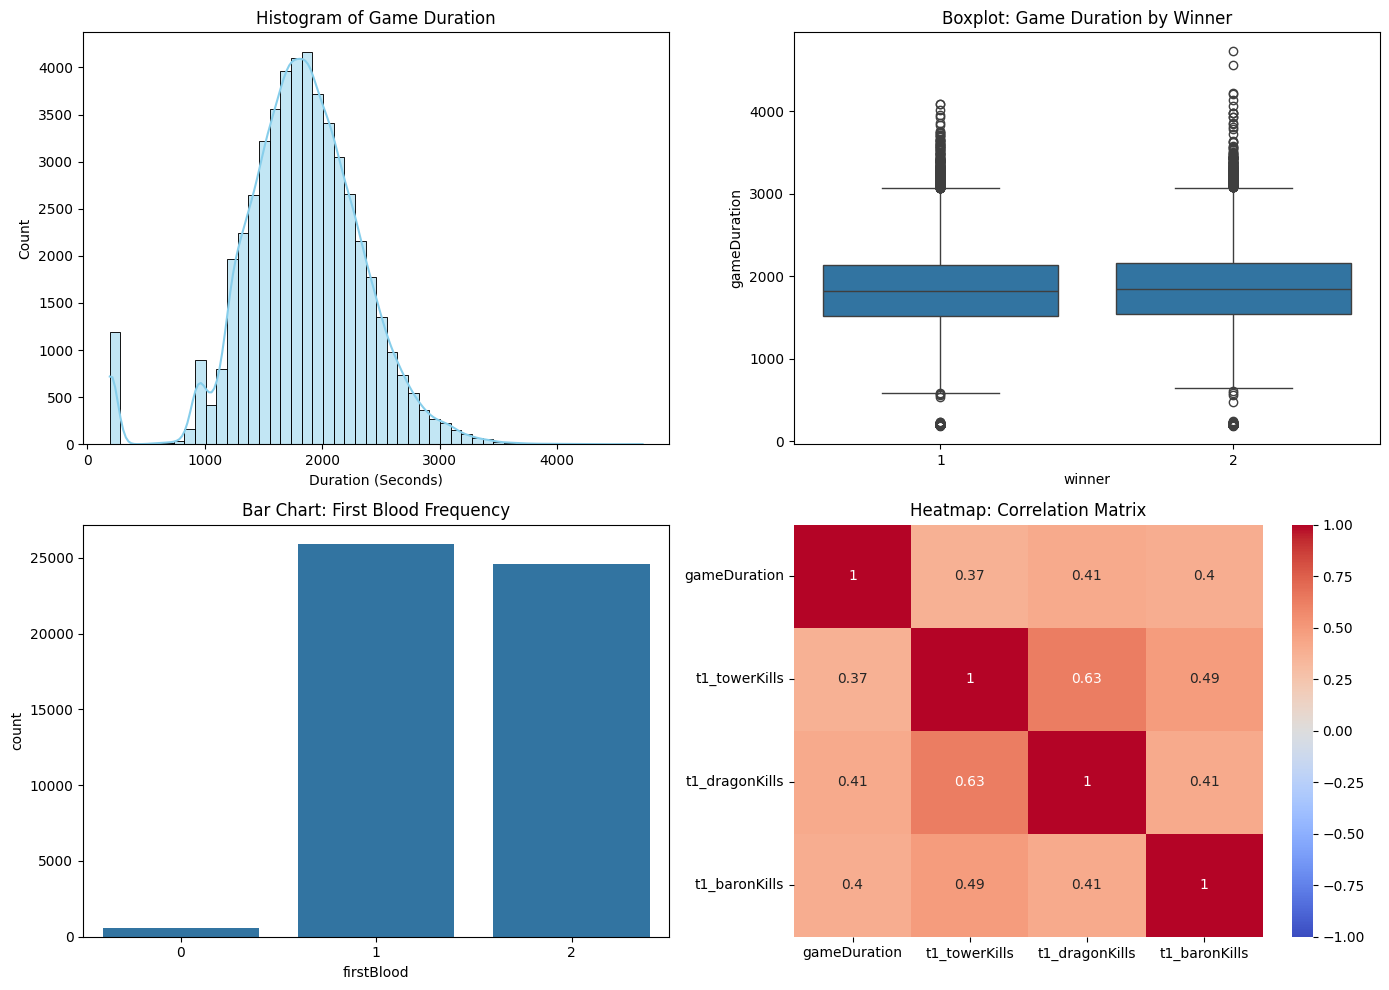

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# נבחר כמה משתנים מספריים מרכזיים לבדיקת קורלציה (כדי לא לייצר מטריצה ענקית מדי)
cols_to_corr = ['gameDuration', 't1_towerKills', 't1_dragonKills', 't1_baronKills']

print("--- 6.1 קורלציות: מספרי-מספרי ---")
print("\n--- Pearson Correlation ---")
print(df[cols_to_corr].corr(method='pearson'))
print("\n--- Spearman Correlation ---")
print(df[cols_to_corr].corr(method='spearman'))
print("\n--- Kendall Correlation ---")
print(df[cols_to_corr].corr(method='kendall'))

# 6.2 קטגוריאלי-קטגוריאלי (טבלת שכיחות: מי לקח First Blood מול מי שניצח)
print("\n--- 6.2 Contingency Table: First Blood vs Winner ---")
contingency = pd.crosstab(df['firstBlood'], df['winner'])
print(contingency)

# 6.3 גרפים
# נגדיר חלון עם 4 תתי-גרפים שונים
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram של זמני המשחק
sns.histplot(df['gameDuration'], bins=50, kde=True, color='skyblue', ax=axes[0,0])
axes[0,0].set_title('Histogram of Game Duration')
axes[0,0].set_xlabel('Duration (Seconds)')

# 2. Boxplot (זמן משחק מול הקבוצה המנצחת)
sns.boxplot(x='winner', y='gameDuration', data=df, ax=axes[0,1])
axes[0,1].set_title('Boxplot: Game Duration by Winner')

# 3. Barchart (מי לקח First Blood)
sns.countplot(x='firstBlood', data=df, ax=axes[1,0])
axes[1,0].set_title('Bar Chart: First Blood Frequency')

# 4. Heatmap של מטריצת הקורלציה (פירסון)
sns.heatmap(df[cols_to_corr].corr(method='pearson'), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1,1])
axes[1,1].set_title('Heatmap: Correlation Matrix')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">
  <h2>6. קורלציות וקשרים</h2>

  <h3>6.1 מספרי-מספרי</h3>
  <ul>
    <li><b>הבדלים בין שיטות הקורלציה:</b>
      <ul>
        <li><b>פירסון (Pearson):</b> בודק קשר ליניארי בין המשתנים. רגיש יותר לערכים חריגים.</li>
        <li><b>ספירמן (Spearman):</b> בודק קשר מונוטוני ומבוסס על דירוג (Ranks). הוא עמיד יותר בפני ערכים חריגים ולכן מציג לעיתים קשרים חזקים יותר בסביבה רועשת.</li>
        <li><b>קנדל (Kendall):</b> מבוסס על זוגות תואמים ולא-תואמים (Concordance). מחמיר יותר מספירמן ולרוב מציג ערכים נמוכים יותר, אך מדויק מאוד למדגמים עם חזרות מרובות (Ties).</li>
      </ul>
    </li>
    <li><b>תובנות ממטריצת הקורלציה:</b>
      <ul>
        <li>קשר חיובי חזק (0.62 בפירסון, 0.64 בספירמן) קיים בין כמות המגדלים שהופלו (<code>t1_towerKills</code>) לכמות הדרקונים שנלקחו (<code>t1_dragonKills</code>). מסקנה: קבוצה שמפעילה לחץ ולוקחת מטרות במפה נוטה לשלוט במספר סוגים של אובייקטים במקביל.</li>
        <li>קשר חיובי מתון (סביב 0.35-0.40) קיים בין משך המשחק לכמות האובייקטים (מגדלים, דרקונים, ברון). הקשר הגיוני טריוויאלית - ככל שהמשחק נמשך יותר זמן, יש לקבוצות יותר הזדמנויות (Respawn time) לקחת עוד אובייקטים.</li>
      </ul>
    </li>
  </ul>

  <h3>6.2 קטגוריאלי-קטגוריאלי</h3>
  <ul>
    <li><b>טבלת שכיחות (Contingency Table):</b> בדקנו את הקשר בין הקבוצה שהשיגה First Blood לקבוצה שניצחה בסוף המשחק.</li>
    <li><b>מסקנות למידע:</b> הנתונים מציגים תמונה מובהקת. כאשר קבוצה 1 משיגה First Blood, כמות הניצחונות שלה עומדת על 15,405 לעומת 10,475 הפסדים (כ-60% סיכויי ניצחון). מגמה זהה לחלוטין נצפית כאשר קבוצה 2 משיגה את ה-First Blood (14,465 ניצחונות לעומת 10,154 הפסדים).
    <br>מכאן ניתן להסיק שהשגת First Blood אינה רק "בונוס" כלכלי קטן בתחילת המשחק, אלא אינדיקטור משמעותי מאוד ליתרון מוקדם שמתורגם בסבירות גבוהה לניצחון.</li>
  </ul>

  <h3>6.3 גרפים</h3>
  <ul>
    <li><b>היסטוגרמה (Histogram):</b> מציגה את התפלגות משכי המשחק. הגרף מאושש את המסקנות מפרק 5 - מדובר בהתפלגות כמעט נורמלית (פעמונית) עם מרכז סביב 30 דקות.</li>
    <li><b>תרשים קופסה (Boxplot):</b> בוחן את זמן המשחק ביחס לזהות הקבוצה המנצחת. ניתן לראות שהקופסאות של t1 ו-t2 כמעט זהות לחלוטין בגודלן, בחציון שלהן, ובפיזור החריגים. מסקנה: אין לקבוצה מסוימת נטייה לנצח מהר יותר. צדדי המפה (כחול/אדום) מאוזנים לחלוטין מבחינת משך הזמן הנדרש לניצחון.</li>
  </ul>
</div>

--- 7. ניתוח אינדקס ---
Is default index unique? True
Is default index sorted (monotonic)? True
Is 'gameId' sorted? False
Is 'creationTime' sorted? False

--- ממוצע משך משחק לפי חודשים (דוגמה) ---
creationTime_dt
2017-06-30    1837.395436
2017-07-31    1843.996025
2017-08-31    1825.020404
2017-09-30    1835.670874
Freq: ME, Name: gameDuration, dtype: float64


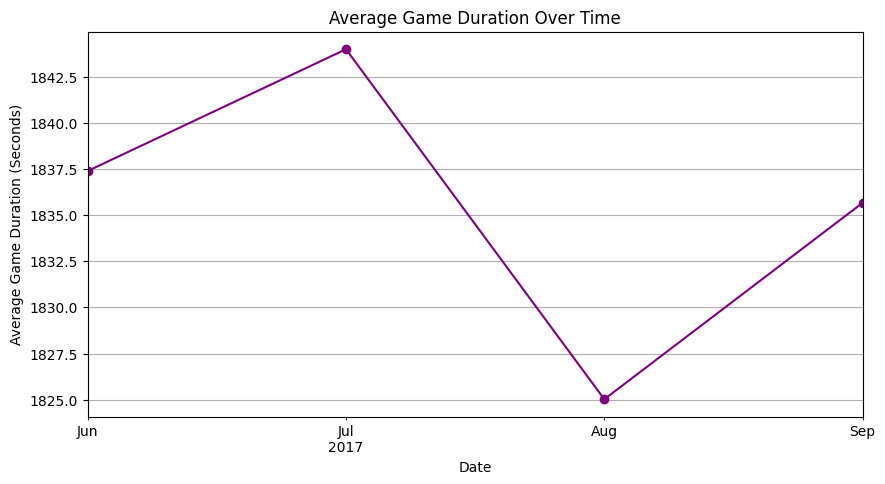

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- 7. ניתוח אינדקס ---")

# נבדוק את האינדקס הדיפולטיבי של המערך
print(f"Is default index unique? {df.index.is_unique}")
print(f"Is default index sorted (monotonic)? {df.index.is_monotonic_increasing}")

# אבל אמרנו ש-gameId הוא האינדקס הלוגי שלנו. נבדוק אותו:
print(f"Is 'gameId' sorted? {df['gameId'].is_monotonic_increasing}")

# נבדוק את עמודת הזמן - creationTime (האם המשחקים מסודרים כרונולוגית?)
print(f"Is 'creationTime' sorted? {df['creationTime'].is_monotonic_increasing}")

# המרת זמן השרת (מילישניות) לתאריך ושעה אמיתיים
df['creationTime_dt'] = pd.to_datetime(df['creationTime'], unit='ms')

# נגדיר את התאריך כאינדקס החדש ונסדר אותו
df_time_indexed = df.set_index('creationTime_dt').sort_index()

# נבדוק אם משך המשחק הממוצע משתנה לאורך החודשים (מענה על "האם הניתוח משתנה בזמן?")
monthly_duration = df_time_indexed['gameDuration'].resample('ME').mean()

print("\n--- ממוצע משך משחק לפי חודשים (דוגמה) ---")
print(monthly_duration.dropna().head())

# ציור גרף לבחינת השינוי בזמן
plt.figure(figsize=(10, 5))
monthly_duration.dropna().plot(kind='line', marker='o', color='purple')
plt.title('Average Game Duration Over Time')
plt.xlabel('Date')
plt.ylabel('Average Game Duration (Seconds)')
plt.grid(True)
plt.show()

<div dir="rtl" style="text-align: right;">
  <h2>7. ניתוח אינדקס</h2>
  <ul>
    <li><b>האם האינדקס ייחודי?</b> אינדקס ברירת המחדל של המערך (RangeIndex) הוא ייחודי. כמו כן, בפרקים קודמים הוכחנו שגם האינדקס הלוגי שלנו, עמודת ה-<code>gameId</code>, מכיל מזהים ייחודיים לכל משחק (לאחר הסרת הכפילויות).</li>
    <li><b>האם מבוסס זמן?</b> האינדקס הדיפולטיבי אינו מבוסס זמן. עם זאת, קיימת במערך עמודת <code>creationTime</code> המייצגת את חותמת הזמן (Timestamp) של תחילת המשחק. על מנת לבצע ניתוח מבוסס זמן, המרנו עמודה זו לפורמט תאריך ושעה (DateTime) והגדרנו אותה כאינדקס זמני.</li>
    <li><b>האם ממוין?</b> מבדיקה שערכנו באמצעות קוד, עולה כי בעוד שאינדקס ברירת המחדל ממוין (מונוטוני עולה), עמודות ה-<code>gameId</code> וה-<code>creationTime</code> <b>אינן ממוינות</b>. המשמעות היא שהמשחקים נשמרו או נדגמו לקובץ שלא לפי סדר כרונולוגי.</li>
    <li><b>האם הניתוח למעלה משתנה בזמן?</b> כדי לענות על כך, דגמנו את משך המשחק הממוצע בחלוקה לחודשים (יוני עד ספטמבר 2017). למרות שהגרף מציג לכאורה תנודתיות, בחינה של ציר ה-Y חושפת כי הפער בין החודש הארוך ביותר לקצר ביותר עומד על כ-18 שניות בלבד. במשחק שאורכו הממוצע כ-30 דקות, מדובר בסטייה זניחה. המסקנה היא שהתנהגות השחקנים ומשך המשחק נותרו יציבים לחלוטין לאורך התקופה, והניתוח הסטטיסטי שלנו תקף לכל אורכה.</li>
  </ul>
</div>

<div dir="rtl" style="text-align: right;">
  <h2>8. תובנות וסיפור הנתונים</h2>
  
  <h3>תובנות מרכזיות</h3>
  <ol>
    <li><b>אפקט כדור השלג (Snowball) והדם הראשון:</b> מצאנו קשר מובהק בין השגת First Blood לבין ניצחון במשחק (כ-60% סיכויי ניצחון לקבוצה שמשיגה אותו). זהו לא רק יתרון כלכלי קטן בתחילת המשחק, אלא אינדיקטור ליתרון פסיכולוגי ואסטרטגי שמתורגם לניצחון.</li>
    <li><b>שליטה גלובלית במפה:</b> קיימת קורלציה חיובית חזקה (מעל 0.6) בין כמות המגדלים המופלים לבין לקיחת דרקונים. קבוצה שמפעילה לחץ נכון ולוקחת מטרות, לרוב מצליחה לשלוט במספר משאבים במקביל ולא מתמקדת רק באפיק אחד.</li>
    <li><b>תופעת משחקי ה-Remake:</b> גילינו קבוצת חריגים מעניינת - משחקים בני כ-3 דקות (190 שניות) שבהם מדד ה-First Blood עומד על 0. נתונים אלו חושפים את מנגנון ביטול המשחקים של המערכת (התנתקות שחקן מוקדמת), ואת הצורך הקריטי בסינון נתונים לפני אימון מודל.</li>
  </ol>

  <h3>הטיות, סיכונים ונקודות כשל למודלי ML</h3>
  <ul>
    <li><b>הטיות במדגם:</b> המערך כולל רק משחקים מדורגים (Ranked). בניית מודל ML על נתונים אלו תיכשל אם ננסה לחזות בעזרתו התנהגות במשחקים רגילים (Normals) או מודים חלופיים (ARAM). בנוסף, לא צוינה רמת השחקנים (Rank/Elo). אם רוב הנתונים נדגמו מרמות נמוכות, המודל עשוי "ללמוד" אסטרטגיות שגויות שאינן רלוונטיות לשחקני עלית.</li>
    <li><b>כשלים באפיון פיצ'רים (Feature Engineering):</b> אם מודל ה-ML יאומן על משחקי ה-Remake כמשחקים רגילים, הוא יסיק בטעות שמשחקים קצרים מסתיימים ללא מגדלים או הריגות, מה שייצור רעש ויפגע בדיוק החיזוי. הסטייה הזו מחייבת סינון מקדים (למשל, הסרת כל משחק שאורכו מתחת ל-5 דקות).</li>
    <li><b>תלות בגרסאות משחק (Patches):</b> המשחק מתעדכן באופן תדיר. אם Riot Games משנים משמעותית נתונים בגרסה מסוימת (למשל מחזקים את הברון), מודל שאומן על עונות קודמות יהפוך ללא רלוונטי ויחווה "Data Drift".</li>
  </ul>

  <h3>מה למדתי בניתוח?</h3>
  <p>הניתוח המחיש לי עד כמה נתונים גולמיים יכולים לספר סיפור אם חוקרים אותם נכון. למדתי שלא תמיד מדדים סטטיסטיים יבשים מספיקים – צריך להכיר את עולם התוכן (Domain Knowledge) כדי להבין שזמן מינימלי של 190 שניות הוא לא באג בנתונים אלא פיצ'ר של המשחק (Remake). בנוסף, נוכחתי לגלות את החשיבות העצומה של ניקוי נתונים (כמו הסרת כפילויות שמצאנו) והבנת הקשרים ביניהם לפני שממהרים ליישם אלגוריתמים של למידת מכונה.</p>
</div>